# Import libraries

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
import geopandas as gpd
import warnings

# Suppress all warnings
warnings.filterwarnings("ignore")

# Your code that might produce warnings

# Data Preprocessing

In [ ]:
df = pd.read_csv("/content/Marine_Fish_Data.csv")

In [ ]:
df.head()

,Species_Name,Region,Breeding_Season,Fishing_Method,Fish_Population,Average_Size(cm),Overfishing_Risk,Water_Temperature(C),Water_Pollution_Level
0,Salmon,North Atlantic,Summer,Net,8270,71.92,No,24.68,High
1,Tuna,Pacific Ocean,Monsoon,Line,1860,85.33,No,21.33,High
2,Cod,Mediterranean Sea,Summer,Line,6390,88.02,No,16.98,Medium
3,Herring,Pacific Ocean,Monsoon,Trawl,6191,85.46,Yes,28.51,Low
4,Herring,Indian Ocean,Monsoon,Trawl,6734,48.35,Yes,25.37,Low


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Species_Name           500 non-null    object 
 1   Region                 500 non-null    object 
 2   Breeding_Season        500 non-null    object 
 3   Fishing_Method         500 non-null    object 
 4   Fish_Population        500 non-null    int64  
 5   Average_Size(cm)       500 non-null    float64
 6   Overfishing_Risk       500 non-null    object 
 7   Water_Temperature(C)   500 non-null    float64
 8   Water_Pollution_Level  500 non-null    object 
dtypes: float64(2), int64(1), object(6)
memory usage: 35.3+ KB


In [ ]:
df.isnull().sum()

,0
Species_Name,0
Region,0
Breeding_Season,0
Fishing_Method,0
Fish_Population,0
Average_Size(cm),0
Overfishing_Risk,0
Water_Temperature(C),0
Water_Pollution_Level,0


In [ ]:
df.shape

(500, 9)

In [ ]:
df

,Species_Name,Region,Breeding_Season,Fishing_Method,Fish_Population,Average_Size(cm),Overfishing_Risk,Water_Temperature(C),Water_Pollution_Level
0,Salmon,North Atlantic,Summer,Net,8270,71.92,No,24.68,High
1,Tuna,Pacific Ocean,Monsoon,Line,1860,85.33,No,21.33,High
2,Cod,Mediterranean Sea,Summer,Line,6390,88.02,No,16.98,Medium
3,Herring,Pacific Ocean,Monsoon,Trawl,6191,85.46,Yes,28.51,Low
4,Herring,Indian Ocean,Monsoon,Trawl,6734,48.35,Yes,25.37,Low
...,...,...,...,...,...,...,...,...,...
495,Salmon,Mediterranean Sea,Monsoon,Trawl,5330,56.12,No,25.29,High
496,Sardine,Pacific Ocean,Monsoon,Line,9010,76.75,No,15.26,Medium
497,Mackerel,Indian Ocean,Summer,Net,7801,72.90,No,19.85,Medium
498,Shark,North Atlantic,Monsoon,Net,5846,46.23,Yes,29.60,Medium


In [ ]:
df.columns

Index(['Species_Name', 'Region', 'Breeding_Season', 'Fishing_Method',
       'Fish_Population', 'Average_Size(cm)', 'Overfishing_Risk',
       'Water_Temperature(C)', 'Water_Pollution_Level'],
      dtype='object')

In [ ]:


# Categorical columns (usually of type object or category)
categorical_columns = df.select_dtypes(include=['object', 'category']).columns.tolist()

# Numerical columns (usually of type int64 or float64)
numerical_columns = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

# Print the results
print("Categorical Columns:")
print(categorical_columns)

print("\nNumerical Columns:")
print(numerical_columns)

Categorical Columns:
['Species_Name', 'Region', 'Breeding_Season', 'Fishing_Method', 'Overfishing_Risk', 'Water_Pollution_Level']

Numerical Columns:
['Fish_Population', 'Average_Size(cm)', 'Water_Temperature(C)']


# Exploratory Data Visual and Analysis (EDA)

In [ ]:


# Categorical columns
categorical_columns = ['Species_Name', 'Region', 'Breeding_Season', 'Fishing_Method', 'Overfishing_Risk', 'Water_Pollution_Level']
numerical_columns = ['Fish_Population', 'Average_Size(cm)', 'Water_Temperature(C)']



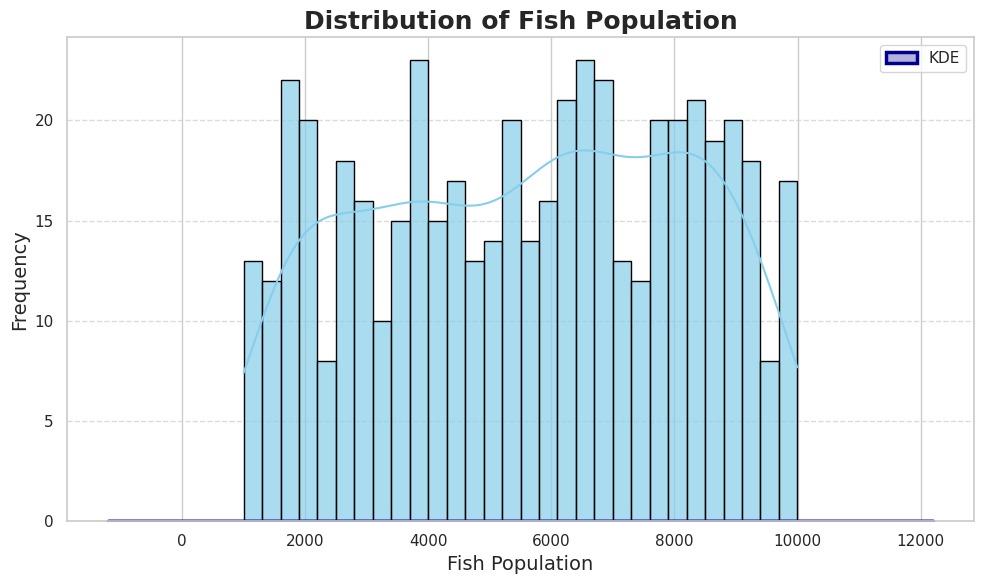

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Set the aesthetic style of the plots
sns.set(style='whitegrid')

# Create the histogram with KDE
plt.figure(figsize=(10, 6))
histplot = sns.histplot(df['Fish_Population'],
                         kde=True,
                         color='skyblue',
                         bins=30,
                         edgecolor='black',  # Add a black edge to bars for better visibility
                         alpha=0.7)  # Slightly transparent bars

# Customize the KDE line
sns.kdeplot(df['Fish_Population'], color='darkblue', linewidth=2.5, label='KDE', fill=True, alpha=0.3)

# Add titles and labels
plt.title('Distribution of Fish Population', fontsize=18, fontweight='bold')
plt.xlabel('Fish Population', fontsize=14)
plt.ylabel('Frequency', fontsize=14)
plt.legend()  # Show legend for KDE line

# Customize grid
plt.grid(axis='y', linestyle='--', alpha=0.7)  # Add horizontal grid lines

# Adjust layout
plt.tight_layout()

# Show the plot
plt.show()


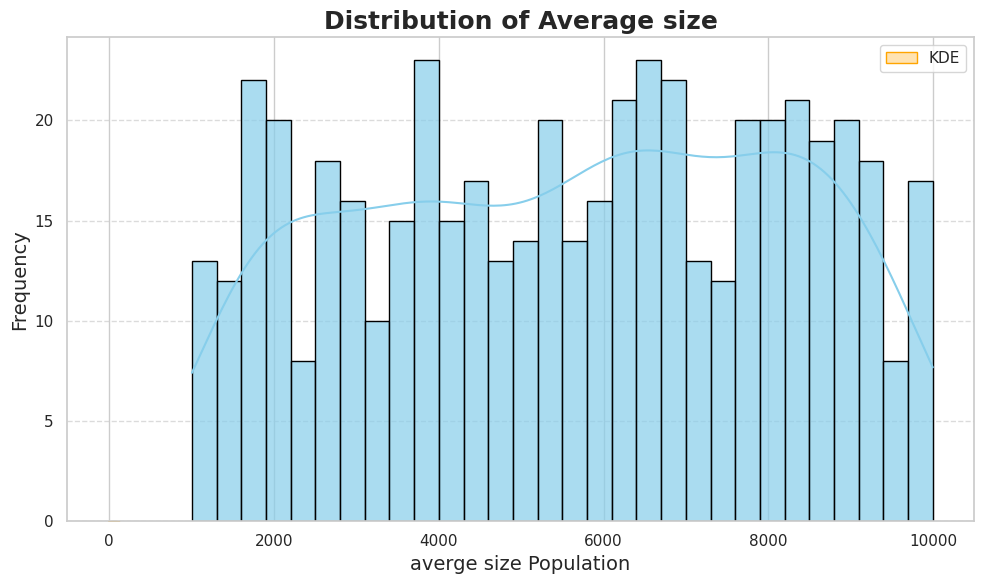

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Set the aesthetic style of the plots
sns.set(style='whitegrid')

# Create the histogram with KDE
plt.figure(figsize=(10, 6))
histplot = sns.histplot(df['Fish_Population'],
                         kde=True,
                         color='skyblue',
                         bins=30,
                         edgecolor='black',  # Add a black edge to bars for better visibility
                         alpha=0.7)  # Slightly transparent bars

# Customize the KDE line for 'Fish_Population'
#sns.kdeplot(df['Fish_Population'], color='darkblue', linewidth=2.5, label='KDE', fill=True, alpha=0.3)

# Customize the KDE line for 'Average_Size(cm)'
# Removed kde=True and bins=30
sns.kdeplot(df['Average_Size(cm)'], color='orange', label='KDE', fill=True, alpha=0.3)

# Add titles and labels
plt.title('Distribution of Average size', fontsize=18, fontweight='bold')
plt.xlabel('averge size Population', fontsize=14)
plt.ylabel('Frequency', fontsize=14)
plt.legend()  # Show legend for KDE line

# Customize grid
plt.grid(axis='y', linestyle='--', alpha=0.7)  # Add horizontal grid lines

# Adjust layout
plt.tight_layout()

# Show the plot
plt.show()

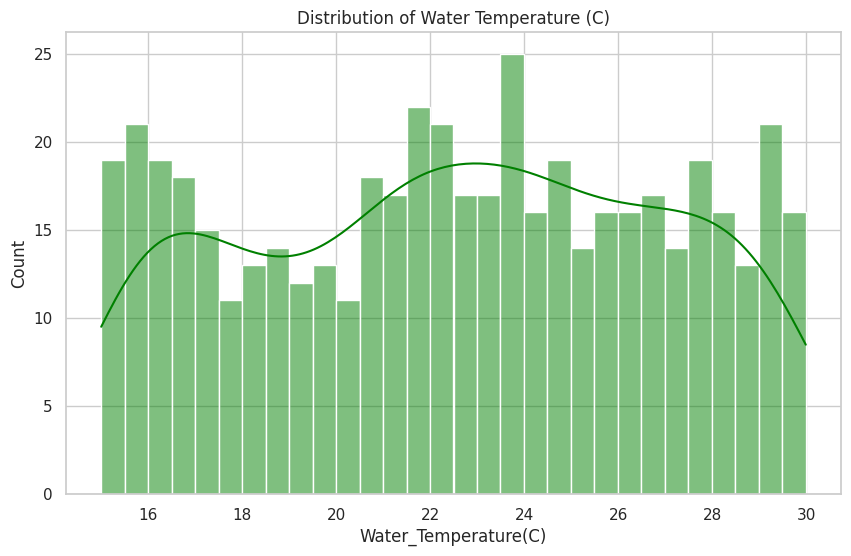

In [ ]:
# 3. Distribution of Water Temperature
plt.figure(figsize=(10, 6))
sns.histplot(df['Water_Temperature(C)'], kde=True, color='green', bins=30)
plt.title('Distribution of Water Temperature (C)')
plt.show()

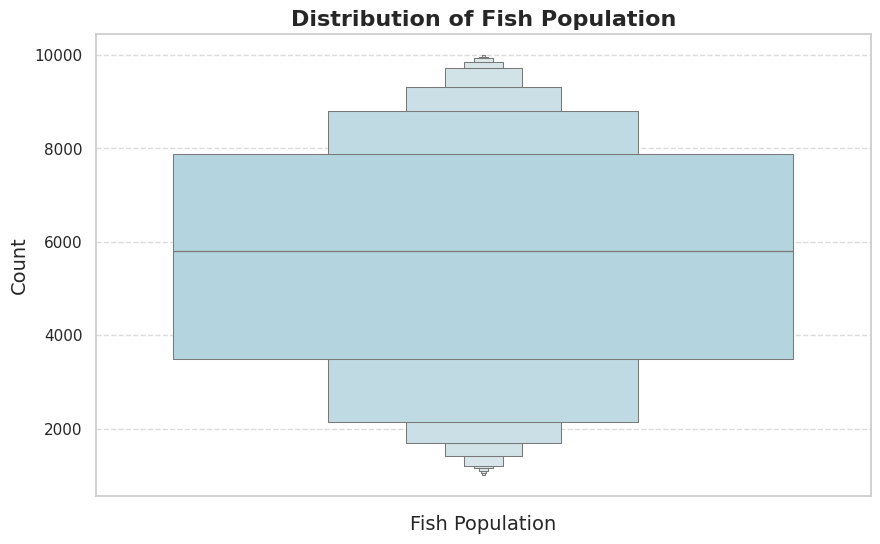

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Setting the aesthetic style of the plot
sns.set(style="whitegrid")

# Create a figure with a specified size
plt.figure(figsize=(10, 6))

# Create a boxen plot for fish population
sns.boxenplot(data=df, y='Fish_Population', color='lightblue', k_depth='full')

# Set the title and labels
plt.title('Distribution of Fish Population', fontsize=16, fontweight='bold')
plt.xlabel('Fish Population', fontsize=14)
plt.ylabel('Count', fontsize=14)

# Add a grid for better readability
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Show the plot
plt.show()

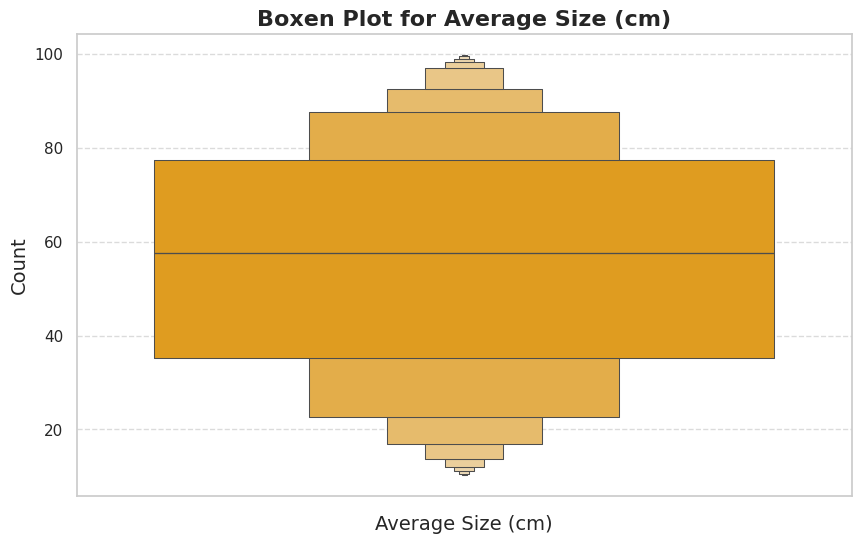

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Setting the aesthetic style of the plot
sns.set(style="whitegrid")

# Create a figure with a specified size
plt.figure(figsize=(10, 6))

# Create a boxen plot for average size
sns.boxenplot(data=df, y='Average_Size(cm)', color='orange', k_depth='full')

# Set the title and labels
plt.title('Boxen Plot for Average Size (cm)', fontsize=16, fontweight='bold')
plt.xlabel('Average Size (cm)', fontsize=14)
plt.ylabel('Count', fontsize=14)

# Add a grid for better readability
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Show the plot
plt.show()

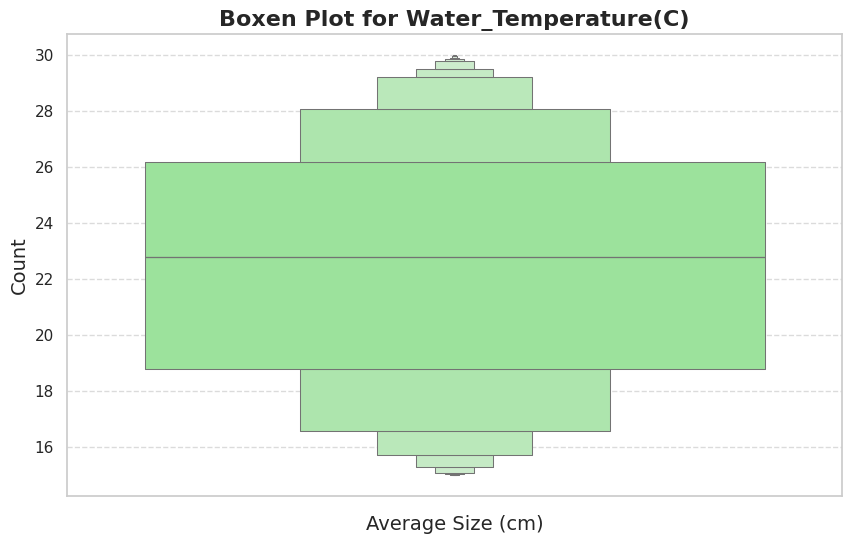

In [ ]:

import matplotlib.pyplot as plt
import seaborn as sns

# Setting the aesthetic style of the plot
sns.set(style="whitegrid")

# Create a figure with a specified size
plt.figure(figsize=(10, 6))

# Create a boxen plot for average size
sns.boxenplot(data=df, y='Water_Temperature(C)', color='lightgreen', k_depth='full')

# Set the title and labels
plt.title('Boxen Plot for Water_Temperature(C)', fontsize=16, fontweight='bold')
plt.xlabel('Average Size (cm)', fontsize=14)
plt.ylabel('Count', fontsize=14)

# Add a grid for better readability
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Show the plot
plt.show()

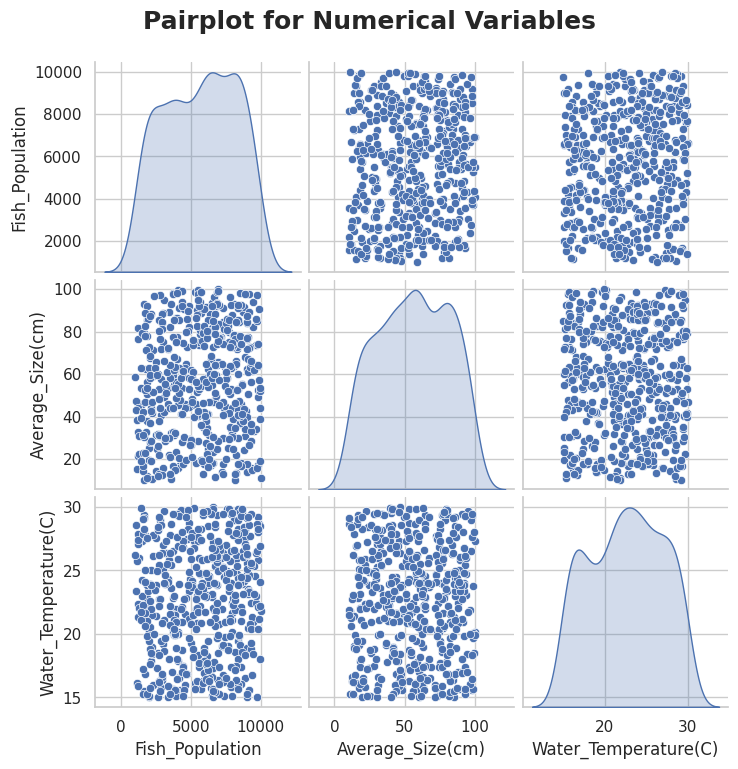

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Set the aesthetic style of the plots
sns.set(style='whitegrid')

# Create the pairplot
pairplot = sns.pairplot(df[numerical_columns],
                         diag_kind='kde',  # Use kernel density estimation for the diagonal
                         palette='viridis',  # Use a color palette
                         markers='o',  # Marker style for scatter plots
                         height=2.5)  # Size of each subplot

# Add a title to the pairplot
plt.suptitle('Pairplot for Numerical Variables', y=1.02, fontsize=18, fontweight='bold')

# Adjust the layout for better spacing
plt.subplots_adjust(top=0.95)

# Show the plot
plt.show()


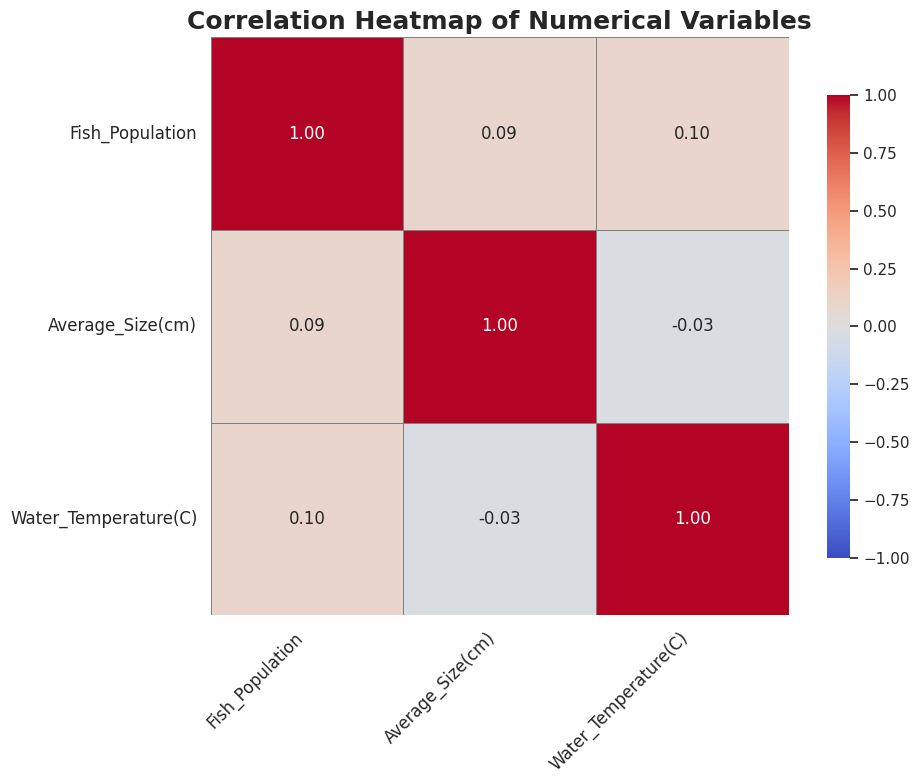

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Calculate the correlation matrix
correlation_matrix = df[numerical_columns].corr()

# Set the aesthetic style of the plots
sns.set(style='white')

# Create the heatmap
plt.figure(figsize=(10, 8))
heatmap = sns.heatmap(correlation_matrix,
                       annot=True,
                       fmt=".2f",  # Format annotations to two decimal places
                       cmap='coolwarm',  # Color palette
                       vmin=-1, vmax=1,  # Set limits for color scale
                       square=True,  # Make squares square-shaped
                       linewidths=0.5,  # Add lines between cells
                       linecolor='gray',  # Color of the lines
                       cbar_kws={"shrink": .8})  # Shrink color bar for better fit

# Add titles and labels
plt.title('Correlation Heatmap of Numerical Variables', fontsize=18, fontweight='bold')
plt.xticks(rotation=45, ha='right', fontsize=12)
plt.yticks(rotation=0, fontsize=12)

# Adjust layout
plt.tight_layout()

# Show the plot
plt.show()


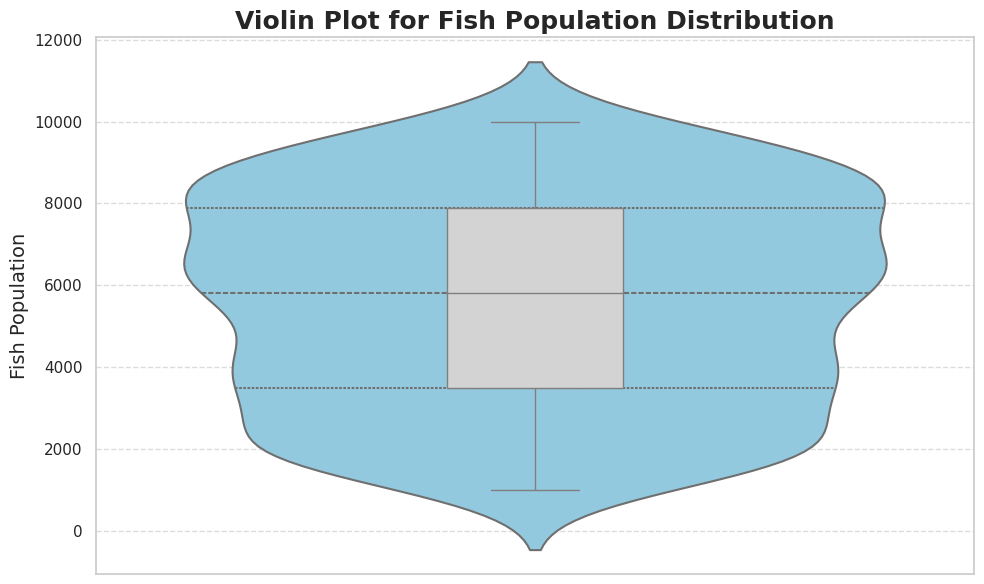

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Set the aesthetic style of the plots
sns.set(style='whitegrid')

# Create the violin plot
plt.figure(figsize=(10, 6))
violin_plot = sns.violinplot(data=df, y='Fish_Population',
                              color='skyblue',
                              inner='quartile',  # Add quartiles to the violin
                              linewidth=1.5)  # Thicker lines for better visibility

# Add a box plot overlay for additional insights
sns.boxplot(data=df, y='Fish_Population', color='lightgray', width=0.2, fliersize=0)

# Add titles and labels
plt.title('Violin Plot for Fish Population Distribution', fontsize=18, fontweight='bold')
plt.ylabel('Fish Population', fontsize=14)
plt.xlabel('')  # No x-label needed for a single variable
plt.grid(axis='y', linestyle='--', alpha=0.7)  # Add horizontal grid lines

# Adjust layout
plt.tight_layout()

# Show the plot
plt.show()


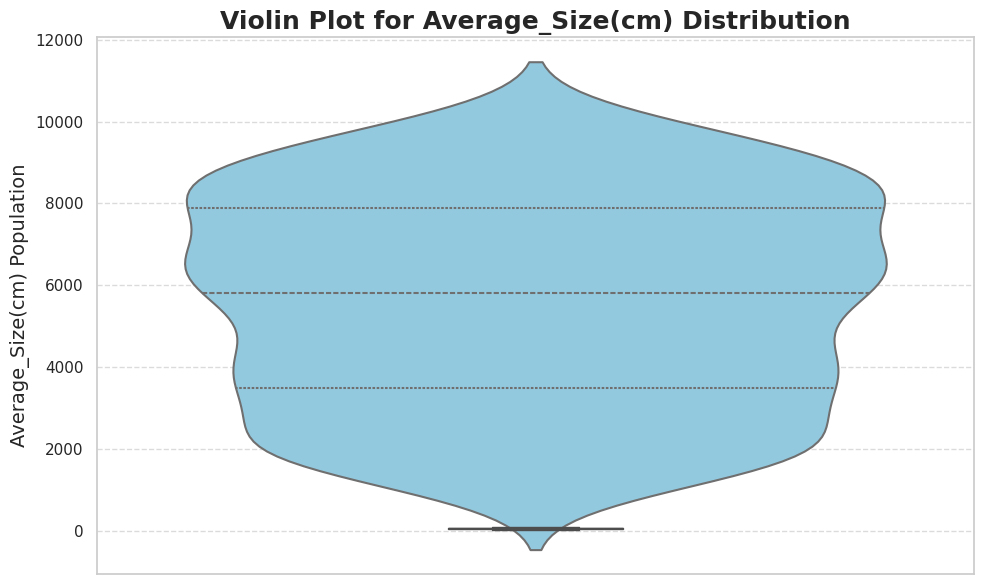

In [ ]:


import seaborn as sns
import matplotlib.pyplot as plt

# Set the aesthetic style of the plots
sns.set(style='whitegrid')

# Create the violin plot
plt.figure(figsize=(10, 6))
violin_plot = sns.violinplot(data=df, y='Fish_Population',
                              color='skyblue',
                              inner='quartile',  # Add quartiles to the violin
                              linewidth=1.5)  # Thicker lines for better visibility

# Add a box plot overlay for additional insights
sns.boxplot(data=df, y='Average_Size(cm)', color='orange', width=0.2, fliersize=0)

# Add titles and labels
plt.title('Violin Plot for Average_Size(cm) Distribution', fontsize=18, fontweight='bold')
plt.ylabel('Average_Size(cm) Population', fontsize=14)
plt.xlabel('')  # No x-label needed for a single variable
plt.grid(axis='y', linestyle='--', alpha=0.7)  # Add horizontal grid lines

# Adjust layout
plt.tight_layout()

# Show the plot
plt.show()


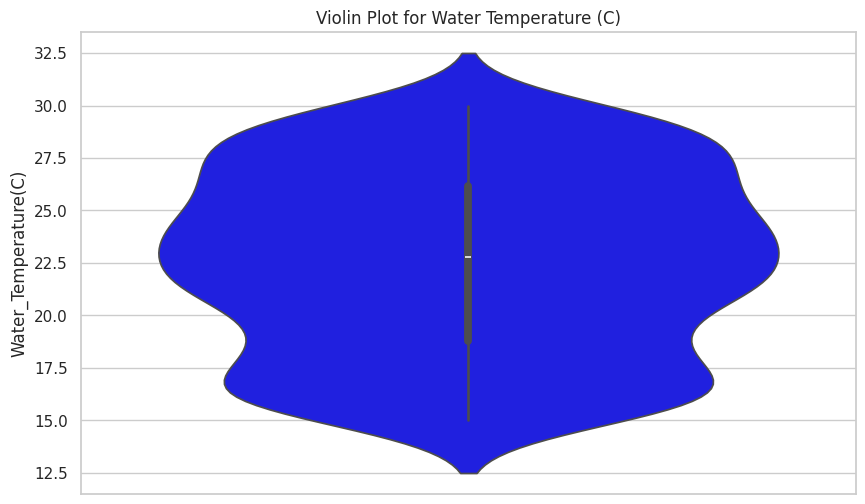

In [ ]:
# 14. Violin plot for Water Temperature distribution
plt.figure(figsize=(10, 6))
sns.violinplot(data=df, y='Water_Temperature(C)', color='blue')
plt.title('Violin Plot for Water Temperature (C)')
plt.show()

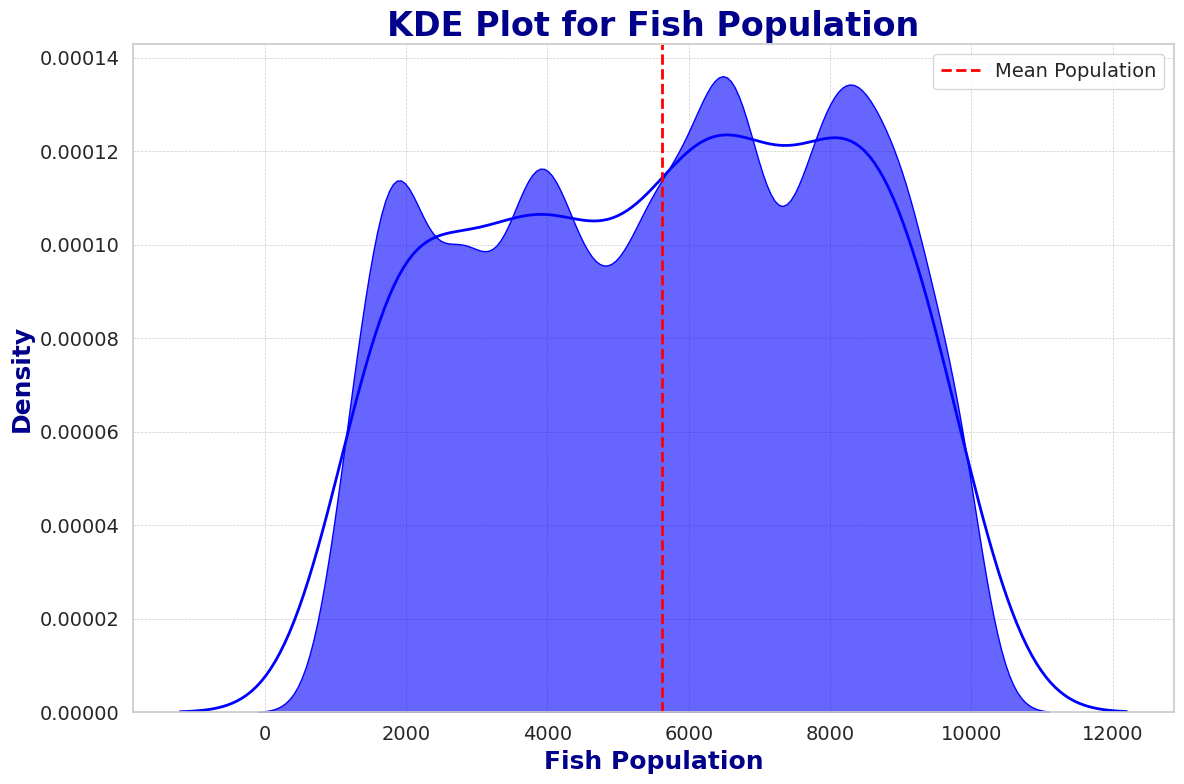

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the aesthetics for the plot
sns.set(style="whitegrid")

# Create the figure with a specified size
plt.figure(figsize=(12, 8))

# Draw the KDE plot with additional parameters for improved aesthetics
sns.kdeplot(data=df, x='Fish_Population', shade=True, color='blue',
             bw_adjust=0.5, # Adjusts the bandwidth
             common_norm=False, # Avoids normalizing across all groups
             alpha=0.6) # Set the transparency of the shaded area

# Deepen the color for the curves
sns.kdeplot(data=df, x='Fish_Population', color='blue', lw=2) # lw line width

# Set title and labels with appropriate fonts
plt.title('KDE Plot for Fish Population', fontsize=24, fontweight='bold', color='darkblue')
plt.xlabel('Fish Population', fontsize=18, fontweight='bold', color='darkblue')
plt.ylabel('Density', fontsize=18, fontweight='bold', color='darkblue')
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

# Optionally, add a vertical line at the mean of the data
mean_population = df['Fish_Population'].mean()
plt.axvline(mean_population, color='red', linestyle='--', linewidth=2, label='Mean Population')
plt.legend(fontsize=14)

# Display the plot
plt.tight_layout() # Adjusts the padding between and around subplots
plt.show()

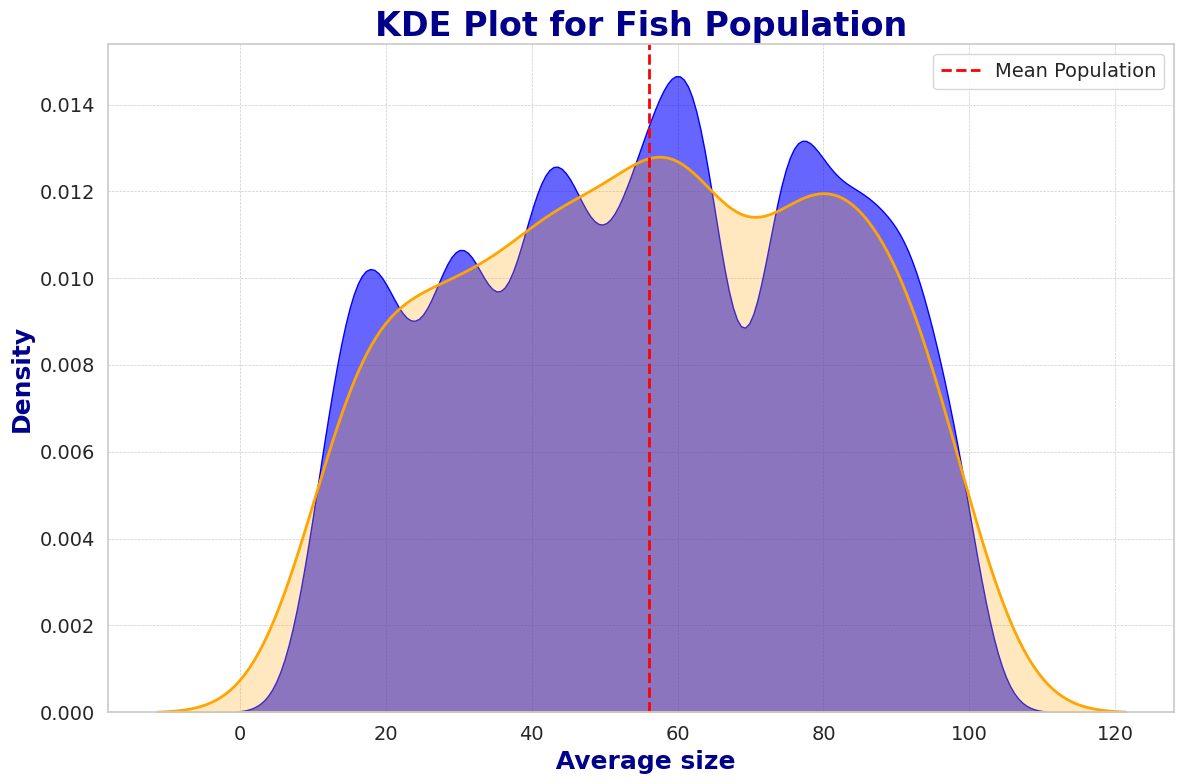

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the aesthetics for the plot
sns.set(style="whitegrid")

# Create the figure with a specified size
plt.figure(figsize=(12, 8))

# Draw the KDE plot with additional parameters for improved aesthetics
sns.kdeplot(data=df, x='Average_Size(cm)', shade=True, color='blue',
             bw_adjust=0.5, # Adjusts the bandwidth
             common_norm=False, # Avoids normalizing across all groups
             alpha=0.6) # Set the transparency of the shaded area

# Deepen the color for the curves
#sns.kdeplot(data=df, x='Fish_Population', color='blue', lw=2) # lw line width
sns.kdeplot(data=df, x='Average_Size(cm)', shade=True, color='orange', lw=2)

# Set title and labels with appropriate fonts
plt.title('KDE Plot for Fish Population', fontsize=24, fontweight='bold', color='darkblue')
plt.xlabel(' Average size', fontsize=18, fontweight='bold', color='darkblue')
plt.ylabel('Density', fontsize=18, fontweight='bold', color='darkblue')
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

# Optionally, add a vertical line at the mean of the data
mean_population = df['Average_Size(cm)'].mean()
plt.axvline(mean_population, color='red', linestyle='--', linewidth=2, label='Mean Population')
plt.legend(fontsize=14)

# Display the plot
plt.tight_layout() # Adjusts the padding between and around subplots
plt.show()

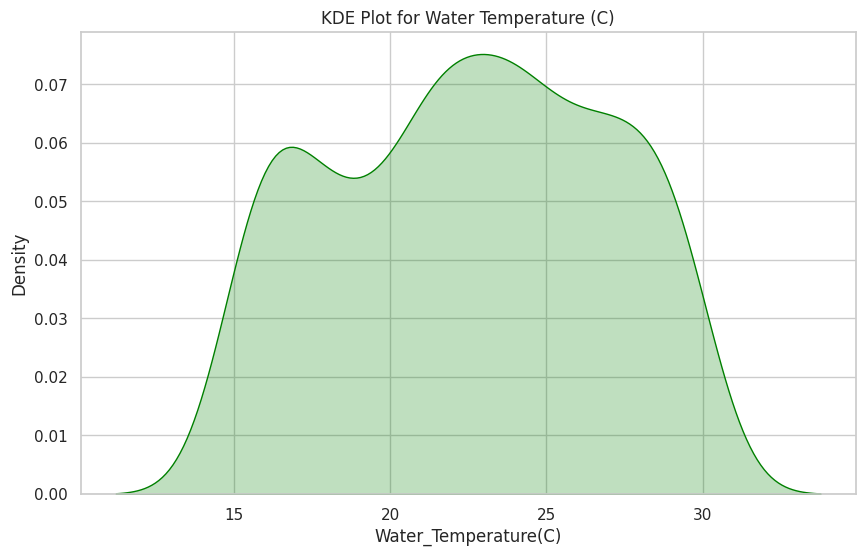

In [ ]:
# 17. KDE plot for Water Temperature
plt.figure(figsize=(10, 6))
sns.kdeplot(data=df, x='Water_Temperature(C)', shade=True, color='green')
plt.title('KDE Plot for Water Temperature (C)')
plt.show()

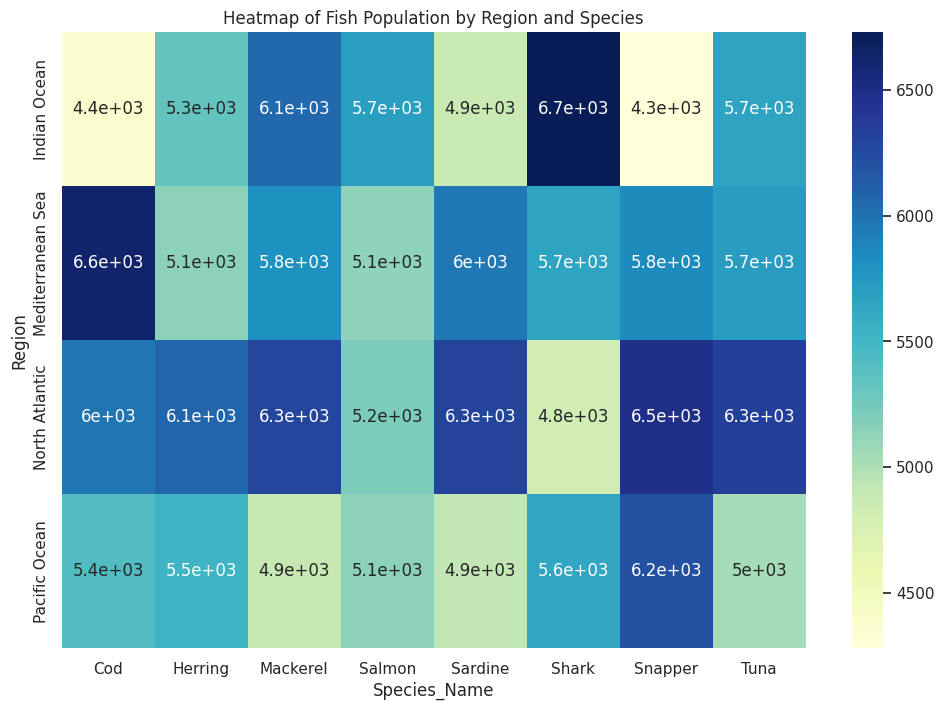

In [ ]:
# 18. Heatmap of Fish Population with Region as categorical overlay
region_pivot = df.pivot_table(index='Region', columns='Species_Name', values='Fish_Population', aggfunc='mean')
plt.figure(figsize=(12, 8))
sns.heatmap(region_pivot, annot=True, cmap='YlGnBu')
plt.title('Heatmap of Fish Population by Region and Species')
plt.show()

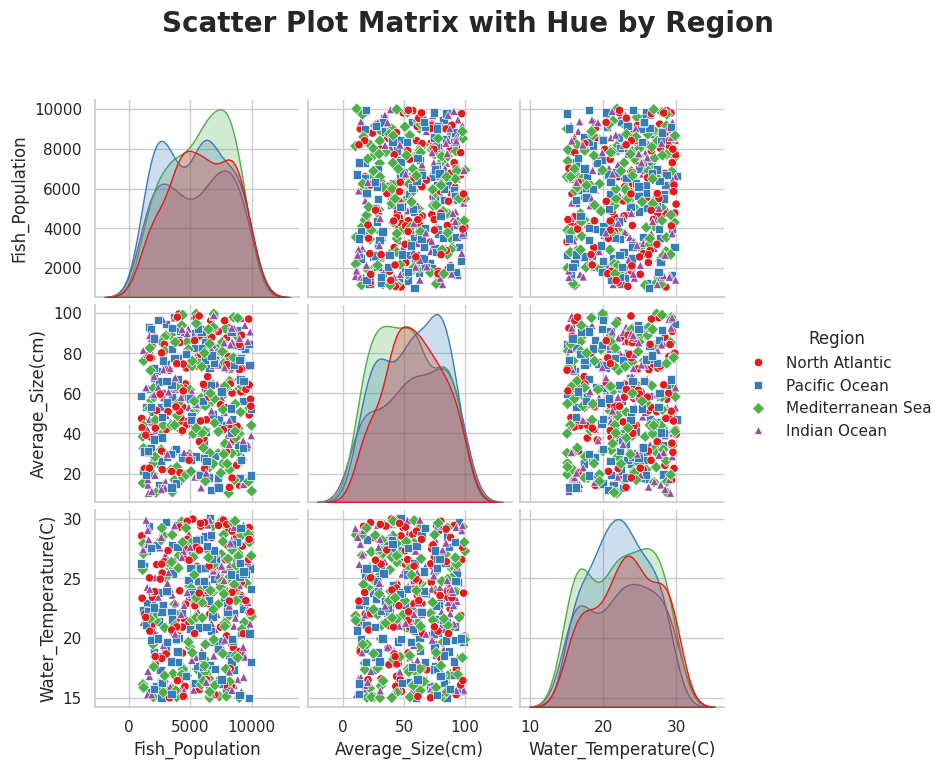

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Set the aesthetic style of the plots
sns.set(style='whitegrid')

# Create the scatter plot matrix (pairplot)
pairplot = sns.pairplot(df,
                         vars=numerical_columns,
                         hue='Region',
                         palette='Set1',  # Use a distinct color palette
                         markers=['o', 's', 'D', '^', 'v'],  # Different markers for each region
                         height=2.5)  # Increase the size of each subplot

# Customize the title
plt.suptitle('Scatter Plot Matrix with Hue by Region', fontsize=20, fontweight='bold', y=1.02)

# Adjust the layout for better spacing
plt.subplots_adjust(top=0.9)  # Adjust top to make room for the title

# Show the plot
plt.show()


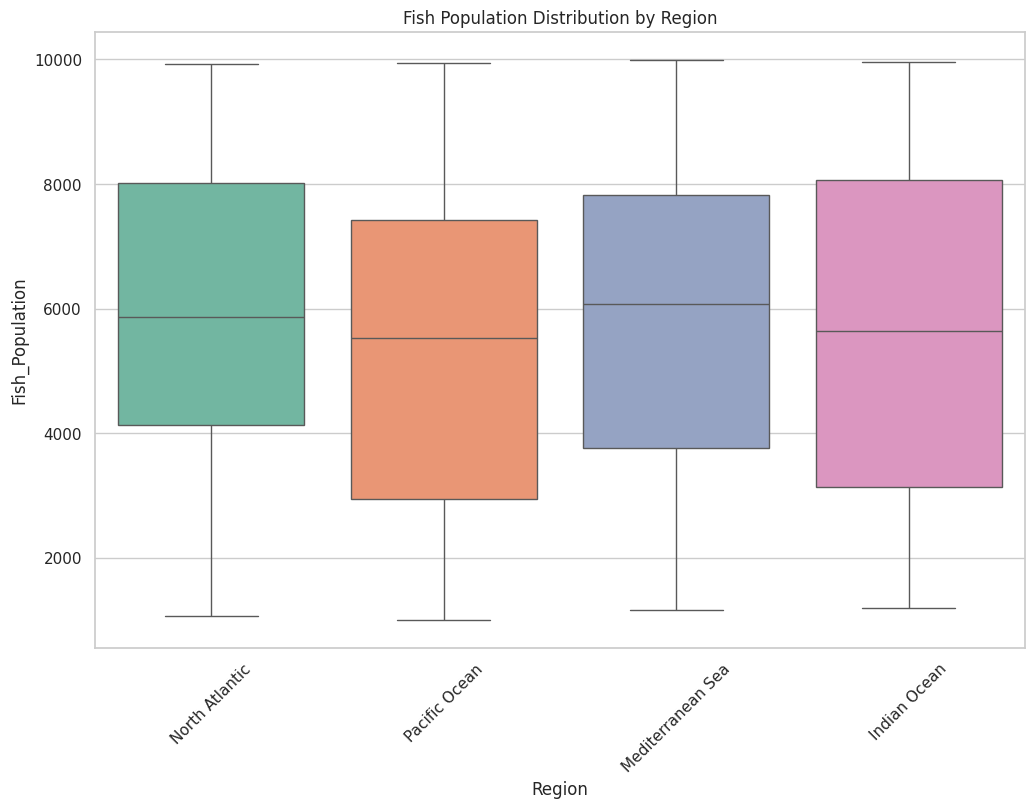

In [ ]:
# 23. Boxplot of Fish Population by Region
plt.figure(figsize=(12, 8))
sns.boxplot(data=df, x='Region', y='Fish_Population', palette='Set2')
plt.title('Fish Population Distribution by Region')
plt.xticks(rotation=45)
plt.show()

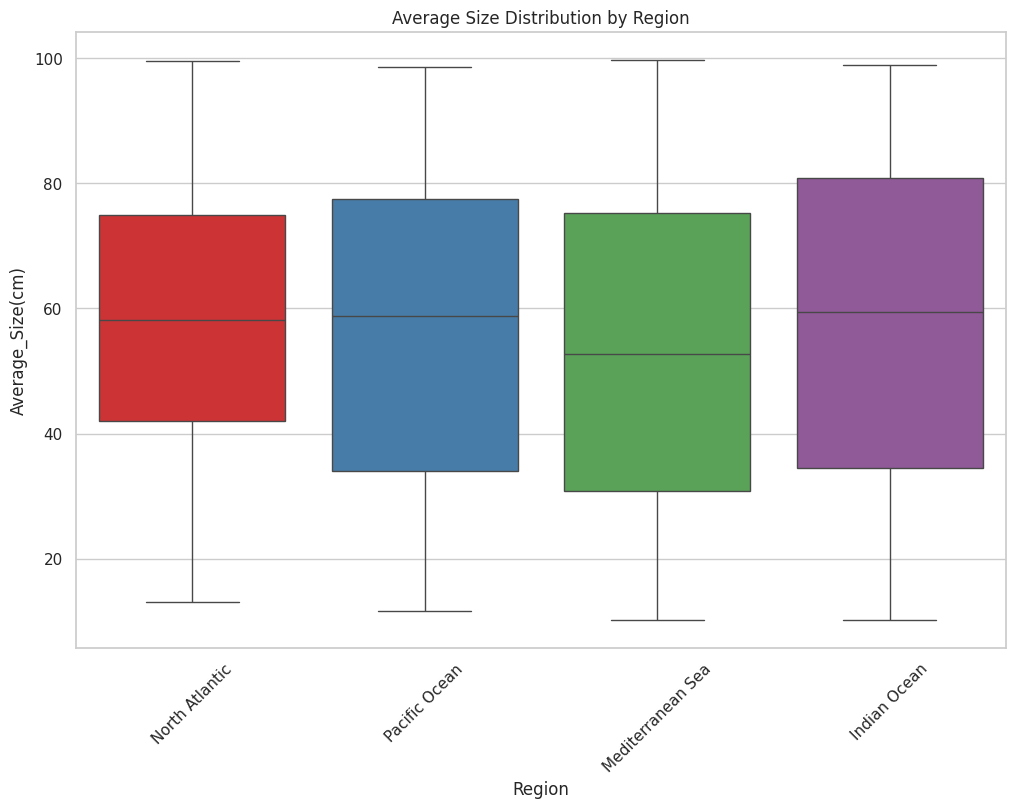

In [ ]:
# 24. Boxplot of Average Size by Region
plt.figure(figsize=(12, 8))
sns.boxplot(data=df, x='Region', y='Average_Size(cm)', palette='Set1')
plt.title('Average Size Distribution by Region')
plt.xticks(rotation=45)
plt.show()

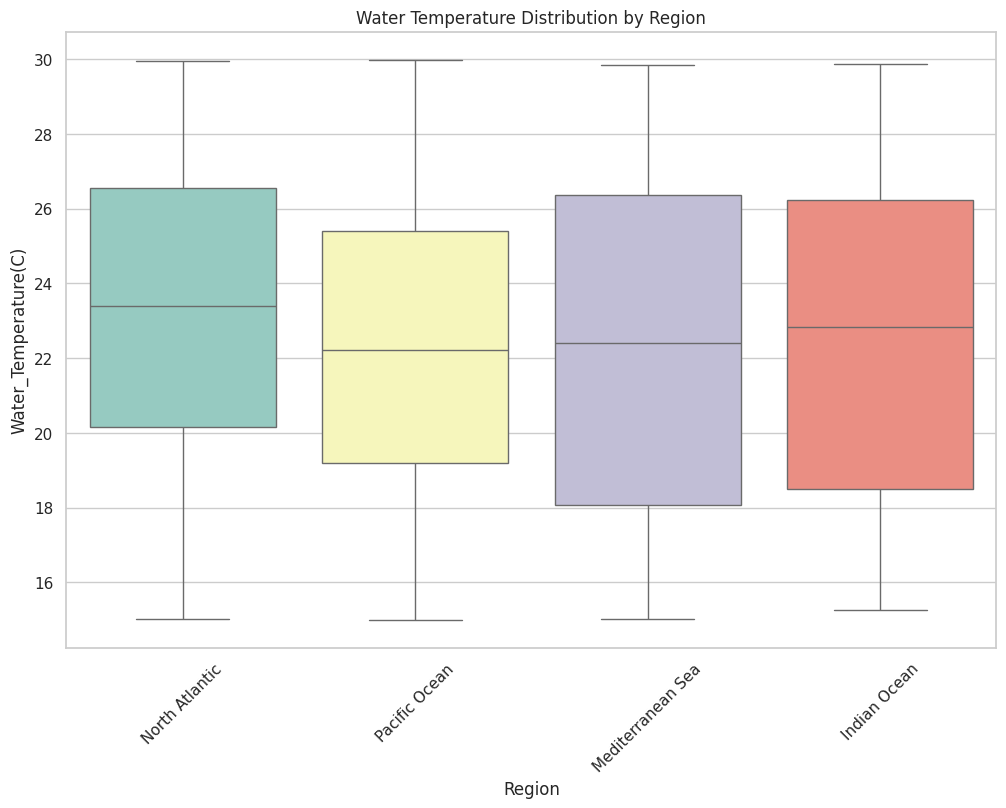

In [ ]:
# 25. Boxplot of Water Temperature by Region
plt.figure(figsize=(12, 8))
sns.boxplot(data=df, x='Region', y='Water_Temperature(C)', palette='Set3')
plt.title('Water Temperature Distribution by Region')
plt.xticks(rotation=45)
plt.show()

In [ ]:
!pip install geopandas
import geopandas as gpd

# Instead of using gpd.datasets.get_path(), download the data directly:
# world = gpd.read_file(gpd.datasets.get_path('naturalearth_lowres')) # This line causes error
# Replace the above line with the following:
world = gpd.read_file("https://naturalearth.s3.amazonaws.com/110m_cultural/ne_110m_admin_0_countries.zip")

df_map = df.groupby('Region').size().reset_index(name='Count')
# The 'world' GeoDataFrame uses 'NAME' as the column for country names, not 'name'
df_map = df_map.merge(world, left_on='Region', right_on='NAME', how='left') # Changed 'name' to 'NAME'

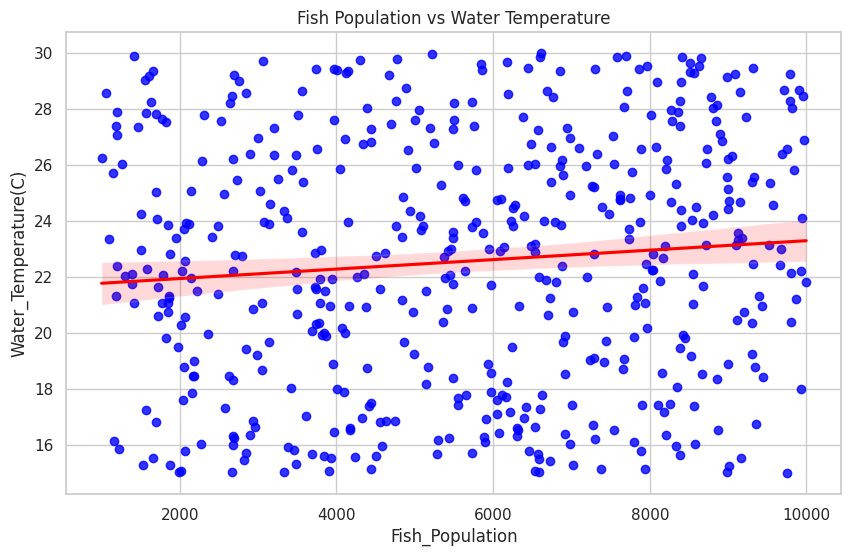

In [ ]:

# 28. Fish Population vs Water Temperature
plt.figure(figsize=(10, 6))
sns.regplot(data=df, x='Fish_Population', y='Water_Temperature(C)', scatter_kws={'color': 'blue'}, line_kws={'color': 'red'})
plt.title('Fish Population vs Water Temperature')
plt.show()

In [ ]:
from shapely.geometry import Point

In [ ]:
print(df.columns)


Index(['Species_Name', 'Region', 'Breeding_Season', 'Fishing_Method',
       'Fish_Population', 'Average_Size(cm)', 'Overfishing_Risk',
       'Water_Temperature(C)', 'Water_Pollution_Level'],
      dtype='object')


# Feature enginerring

# Feature engineering pipline

In [ ]:
import pandas as pd
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder

class InteractionFeatureCreator(BaseEstimator, TransformerMixin):
    def __init__(self, feature1, feature2):
        self.feature1 = feature1
        self.feature2 = feature2

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X_transformed = X.copy()  # Create a copy of the DataFrame
        # Create interaction feature using f-string formatting
        X_transformed[f'{self.feature1}_{self.feature2}'] = X_transformed[self.feature1] * X_transformed[self.feature2]
        return X_transformed

# Define the features and target
X = df.drop('Species_Name', axis=1)
y = df['Species_Name']

# Define numerical and categorical features
# Remove 'Fish_Population_Average_Size(cm)' from numerical_features
numerical_features = ['Fish_Population', 'Average_Size(cm)']
categorical_features = ['Region']

# Create separate pipelines for numerical and categorical features
numerical_pipeline = Pipeline([
    ('interaction', InteractionFeatureCreator('Fish_Population', 'Average_Size(cm)')), # Create interaction feature
    ('scaler', StandardScaler()),  # Scale numerical features
])

categorical_pipeline = Pipeline([
    ('encoder', OneHotEncoder(handle_unknown='ignore'))  # Encode categorical features
])

# Use ColumnTransformer to combine the pipelines
# Update numerical_features in ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_pipeline, numerical_features),
        ('cat', categorical_pipeline, categorical_features)
    ])

# Create the final pipeline
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor)
])

# Fit and transform the data
X_transformed = pipeline.fit_transform(X)

# Convert the transformed data back to a DataFrame for easier inspection
# Get feature names from both pipelines
# Use numerical_features and interaction feature name for get_feature_names_out
numerical_feature_names = preprocessor.named_transformers_['num']['scaler'].get_feature_names_out(numerical_features + ['Fish_Population_Average_Size(cm)'])
categorical_feature_names = preprocessor.named_transformers_['cat']['encoder'].get_feature_names_out(categorical_features)
all_feature_names = list(numerical_feature_names) + list(categorical_feature_names)

# Remove .toarray() from the following line:
X_transformed_df = pd.DataFrame(X_transformed, columns=all_feature_names)
# Display the transformed DataFrame
print(X_transformed_df)

     Fish_Population  Average_Size(cm)  Fish_Population_Average_Size(cm)  \
0           1.040265          0.637468                          1.286751   
1          -1.484373          1.175206                         -0.763163   
2           0.299810          1.283075                          1.134767   
3           0.221432          1.180419                          0.977920   
4           0.435297         -0.307684                          0.021307   
..               ...               ...                               ...   
495        -0.117681          0.003891                         -0.103124   
496         1.331721          0.831150                          1.741516   
497         0.855545          0.676766                          1.164125   
498         0.085550         -0.392696                         -0.238788   
499         0.827975         -1.058753                         -0.432789   

     Region_Indian Ocean  Region_Mediterranean Sea  Region_North Atlantic  \
0         

In [ ]:
print(pipeline)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('interaction',
                                                                   InteractionFeatureCreator(feature1='Fish_Population',
                                                                                             feature2='Average_Size(cm)')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Fish_Population',
                                                   'Average_Size(cm)']),
                                                 ('cat',
                                                  Pipeline(steps=[('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                              

In [ ]:
params = pipeline.get_params()
for name, param in params.items():
    print(f"{name}: {param}")

memory: None
steps: [('preprocessor', ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('interaction',
                                                  InteractionFeatureCreator(feature1='Fish_Population',
                                                                            feature2='Average_Size(cm)')),
                                                 ('scaler', StandardScaler())]),
                                 ['Fish_Population', 'Average_Size(cm)']),
                                ('cat',
                                 Pipeline(steps=[('encoder',
                                                  OneHotEncoder(handle_unknown='ignore'))]),
                                 ['Region'])]))]
verbose: False
preprocessor: ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('interaction',
                                                  InteractionFeatureCreator(feature1='Fish_Population',
         

In [ ]:
print(pipeline)

# Get and print detailed parameters
params = pipeline.get_params()
for name, param in params.items():
    print(f"{name}: {param}")

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('interaction',
                                                                   InteractionFeatureCreator(feature1='Fish_Population',
                                                                                             feature2='Average_Size(cm)')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Fish_Population',
                                                   'Average_Size(cm)']),
                                                 ('cat',
                                                  Pipeline(steps=[('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                              

#  Model Buildings

In [ ]:

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder



# Handle missing values
df = df.dropna()

# Encode categorical columns using one-hot encoding
df = pd.get_dummies(df, drop_first=True)

# Separate the features (X) and target (y)
X = df.drop('Overfishing_Risk_Yes', axis=1)  # Assuming Overfishing_Risk is the target
y = df['Overfishing_Risk_Yes']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Scale numerical features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


# LR

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

# Logistic Regression
lr_model = LogisticRegression()
lr_model.fit(X_train, y_train)
y_pred_lr = lr_model.predict(X_test)
print(classification_report(y_test, y_pred_lr))


              precision    recall  f1-score   support

       False       0.55      0.53      0.54        83
        True       0.44      0.46      0.45        67

    accuracy                           0.50       150
   macro avg       0.50      0.50      0.50       150
weighted avg       0.50      0.50      0.50       150



# SVM

In [ ]:
from sklearn.svm import SVC

# SVM
svm_model = SVC()
svm_model.fit(X_train, y_train)
y_pred_svm = svm_model.predict(X_test)
print(classification_report(y_test, y_pred_svm))

              precision    recall  f1-score   support

       False       0.60      0.31      0.41        83
        True       0.47      0.75      0.57        67

    accuracy                           0.51       150
   macro avg       0.54      0.53      0.49       150
weighted avg       0.54      0.51      0.49       150



# DT

In [ ]:
from sklearn.tree import DecisionTreeClassifier

# Decision Tree
dt_model = DecisionTreeClassifier()
dt_model.fit(X_train, y_train)
y_pred_dt = dt_model.predict(X_test)
print(classification_report(y_test, y_pred_dt))

              precision    recall  f1-score   support

       False       0.56      0.58      0.57        83
        True       0.45      0.43      0.44        67

    accuracy                           0.51       150
   macro avg       0.51      0.51      0.51       150
weighted avg       0.51      0.51      0.51       150



# RT

In [ ]:
from sklearn.ensemble import RandomForestClassifier

# Random Forest
rf_model = RandomForestClassifier()
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

       False       0.59      0.58      0.58        83
        True       0.49      0.49      0.49        67

    accuracy                           0.54       150
   macro avg       0.54      0.54      0.54       150
weighted avg       0.54      0.54      0.54       150



# GB

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier

# Gradient Boosting
gb_model = GradientBoostingClassifier()
gb_model.fit(X_train, y_train)
y_pred_gb = gb_model.predict(X_test)
print(classification_report(y_test, y_pred_gb))

              precision    recall  f1-score   support

       False       0.57      0.58      0.57        83
        True       0.47      0.46      0.47        67

    accuracy                           0.53       150
   macro avg       0.52      0.52      0.52       150
weighted avg       0.53      0.53      0.53       150



# Catsboost

In [ ]:
# Install catboost if not already installed
!pip install catboost

# Import necessary libraries
from catboost import CatBoostClassifier

# CatBoost
cat_model = CatBoostClassifier(silent=True)
cat_model.fit(X_train, y_train)
y_pred_cat = cat_model.predict(X_test)
print(classification_report(y_test, y_pred_cat))

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.7/98.7 MB 4.7 MB/s eta 0:00:00
              precision    recall  f1-score   support

       False       0.59      0.54      0.57        83
        True       0.49      0.54      0.51        67

    accuracy                           0.54       150
   macro avg       0.54      0.54      0.54       150
weighted avg       0.54      0.54      0.54       150



# KNN

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

# KNN
knn_model = KNeighborsClassifier()
knn_model.fit(X_train, y_train)
y_pred_knn = knn_model.predict(X_test)
print(classification_report(y_test, y_pred_knn))

              precision    recall  f1-score   support

       False       0.53      0.49      0.51        83
        True       0.42      0.45      0.43        67

    accuracy                           0.47       150
   macro avg       0.47      0.47      0.47       150
weighted avg       0.48      0.47      0.47       150



In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import classification_report


# Define RandomForest and hyperparameter grid
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 20, 30, None],
    'min_samples_split': [2, 5, 10]
}
clf = RandomForestClassifier(random_state=42)
clf.fit(X_train, y_train)

# Grid Search
grid_search = GridSearchCV(estimator=clf, param_grid=param_grid, cv=3, verbose=2, n_jobs=-1)
grid_search.fit(X_train, y_train)

# Best parameters and evaluation
print(f"Best Parameters: {grid_search.best_params_}")
y_pred = grid_search.best_estimator_.predict(X_test)
print(classification_report(y_test, y_pred))


Fitting 3 folds for each of 36 candidates, totalling 108 fits
Best Parameters: {'max_depth': 20, 'min_samples_split': 10, 'n_estimators': 100}
              precision    recall  f1-score   support

       False       0.59      0.54      0.57        83
        True       0.49      0.54      0.51        67

    accuracy                           0.54       150
   macro avg       0.54      0.54      0.54       150
weighted avg       0.54      0.54      0.54       150



In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Conv1D, Flatten, Dropout

# Normalize data
X_train_normalized = X_train / X_train.max()
X_test_normalized = X_test / X_test.max()

# CNN Model for tabular data (adjust for your dataset)
model = Sequential([
    Conv1D(filters=32, kernel_size=3, activation='relu', input_shape=(X_train_normalized.shape[1], 1)),
    Flatten(),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')  # Use softmax for multi-class classification
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Reshape input data for CNN
# Convert to float32 before reshaping
X_train_cnn = X_train_normalized.values.astype('float32').reshape(-1, X_train_normalized.shape[1], 1)
X_test_cnn = X_test_normalized.values.astype('float32').reshape(-1, X_test_normalized.shape[1], 1)

# Train
history = model.fit(X_train_cnn, y_train, epochs=20, validation_split=0.2, batch_size=32)

# Evaluate
test_loss, test_acc = model.evaluate(X_test_cnn, y_test)
print(f"Test Accuracy: {test_acc}")

Epoch 1/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 3s 51ms/step - accuracy: 0.5216 - loss: 0.6929 - val_accuracy: 0.4000 - val_loss: 0.7186
Epoch 2/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.5445 - loss: 0.6761 - val_accuracy: 0.4000 - val_loss: 0.7332
Epoch 3/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.6074 - loss: 0.6557 - val_accuracy: 0.4429 - val_loss: 0.7318
Epoch 4/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.6100 - loss: 0.6523 - val_accuracy: 0.4143 - val_loss: 0.7196
Epoch 5/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.6366 - loss: 0.6583 - val_accuracy: 0.3857 - val_loss: 0.7240
Epoch 6/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.6602 - loss: 0.6566 - val_accuracy: 0.4286 - val_loss: 0.7417
Epoch 7/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.6626 - loss: 0.6348 - val_accuracy: 0.4429 - val_loss: 0.7486
Epoch 8/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.6345 - loss: 0.6459 - val_accuracy: 0.3857 - val_loss: 0.7442
Ep

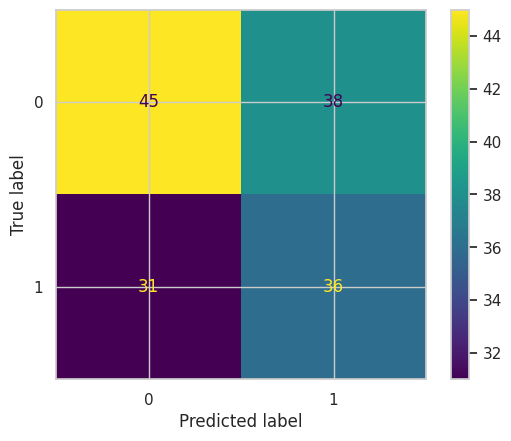

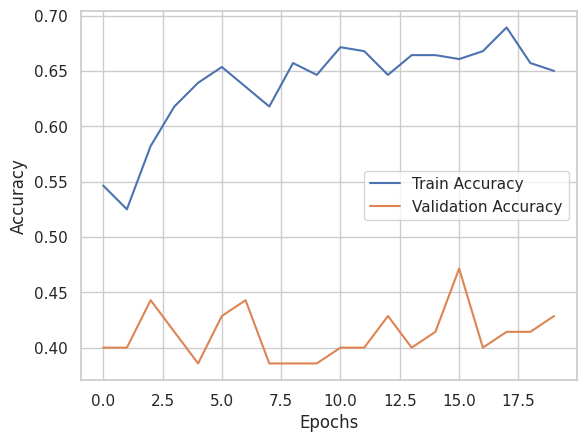

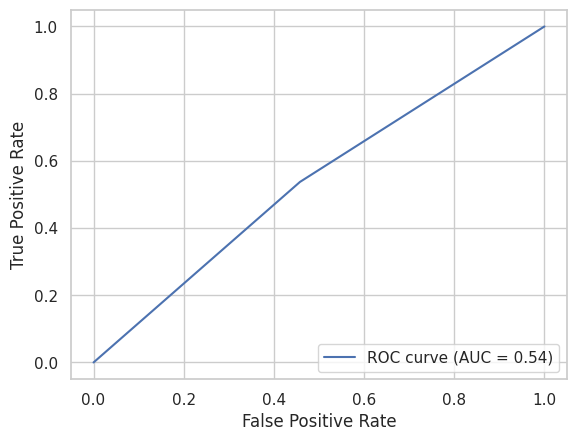

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.show()

# Accuracy/Loss Curves
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_pred)
roc_auc = auc(fpr, tpr)
plt.plot(fpr, tpr, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.show()


In [ ]:
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

# Resample the data
sm = SMOTE(random_state=42)
X_res, y_res = sm.fit_resample(X, y)

# Split into train/test sets
X_train, X_test, y_train, y_test = train_test_split(X_res, y_res, test_size=0.2, random_state=42)

# Train XGBoost model
model = XGBClassifier()
model.fit(X_train, y_train)

# Evaluate
y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

       False       0.53      0.65      0.58        48
        True       0.60      0.48      0.54        54

    accuracy                           0.56       102
   macro avg       0.57      0.56      0.56       102
weighted avg       0.57      0.56      0.56       102



CatBoost Classification Report:
              precision    recall  f1-score   support

       False       0.58      0.71      0.64        48
        True       0.67      0.54      0.60        54

    accuracy                           0.62       102
   macro avg       0.63      0.62      0.62       102
weighted avg       0.63      0.62      0.62       102



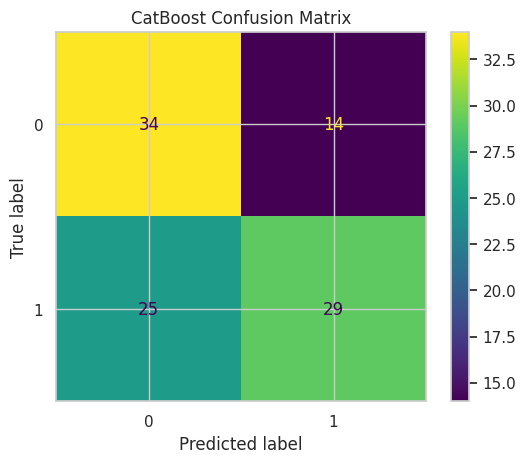

In [ ]:
from catboost import CatBoostClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

# Initialize and train CatBoost
cat_model = CatBoostClassifier(iterations=500, learning_rate=0.1, depth=6, verbose=0, random_seed=42)
cat_model.fit(X_train, y_train)

# Predictions
y_pred_cat = cat_model.predict(X_test)

# Evaluate CatBoost
print("CatBoost Classification Report:")
print(classification_report(y_test, y_pred_cat))

# Confusion Matrix
cm_cat = confusion_matrix(y_test, y_pred_cat)
disp_cat = ConfusionMatrixDisplay(confusion_matrix=cm_cat)
disp_cat.plot()
plt.title("CatBoost Confusion Matrix")
plt.show()


KNN Classification Report:
              precision    recall  f1-score   support

       False       0.49      0.54      0.51        48
        True       0.55      0.50      0.52        54

    accuracy                           0.52       102
   macro avg       0.52      0.52      0.52       102
weighted avg       0.52      0.52      0.52       102



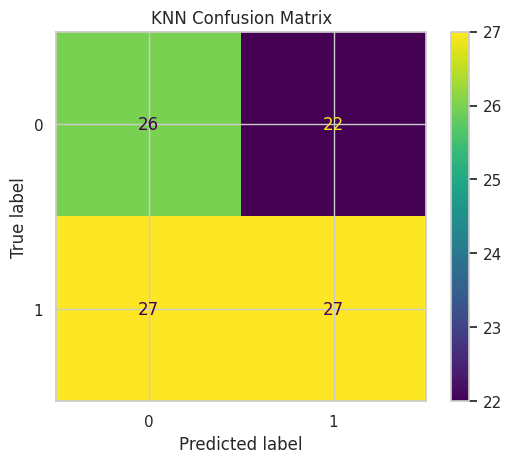

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train KNN
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train_scaled, y_train)

# Predictions
y_pred_knn = knn_model.predict(X_test_scaled)

# Evaluate KNN
print("KNN Classification Report:")
print(classification_report(y_test, y_pred_knn))

# Confusion Matrix
cm_knn = confusion_matrix(y_test, y_pred_knn)
disp_knn = ConfusionMatrixDisplay(confusion_matrix=cm_knn)
disp_knn.plot()
plt.title("KNN Confusion Matrix")
plt.show()


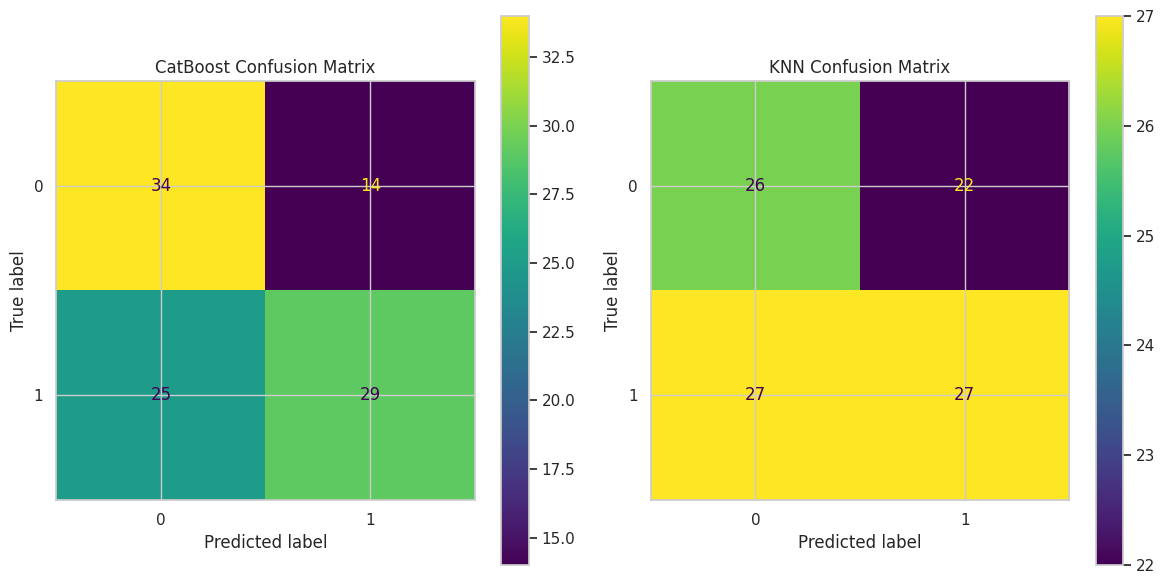

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# CatBoost Confusion Matrix
disp_cat = ConfusionMatrixDisplay(confusion_matrix=cm_cat)
disp_cat.plot(ax=axes[0])
axes[0].set_title("CatBoost Confusion Matrix")

# KNN Confusion Matrix
disp_knn = ConfusionMatrixDisplay(confusion_matrix=cm_knn)
disp_knn.plot(ax=axes[1])
axes[1].set_title("KNN Confusion Matrix")

plt.tight_layout()
plt.show()


# Gridsearch

In [ ]:
from sklearn.model_selection import GridSearchCV

cat_params = {
    'iterations': [200, 500, 1000],
    'learning_rate': [0.01, 0.1, 0.2],
    'depth': [4, 6, 8]
}

cat_grid = GridSearchCV(estimator=CatBoostClassifier(verbose=0, random_seed=42), param_grid=cat_params, cv=3, n_jobs=-1)
cat_grid.fit(X_train, y_train)

print(f"Best CatBoost Parameters: {cat_grid.best_params_}")


Best CatBoost Parameters: {'depth': 4, 'iterations': 500, 'learning_rate': 0.2}


In [ ]:
knn_params = {
    'n_neighbors': [3, 5, 7],
    'weights': ['uniform', 'distance'],
    'p': [1, 2]  # 1 for Manhattan, 2 for Euclidean distance
}

knn_grid = GridSearchCV(estimator=KNeighborsClassifier(), param_grid=knn_params, cv=3, n_jobs=-1)
knn_grid.fit(X_train_scaled, y_train)

print(f"Best KNN Parameters: {knn_grid.best_params_}")


Best KNN Parameters: {'n_neighbors': 7, 'p': 1, 'weights': 'uniform'}
